In [ ]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.07
T = 1
nu = 0.12
sig1 = 0.3
sig2 = 0.4
p = 2
l = 0.005
N = 100 
mc = 10000
dt = T / N
O = 0.6
 
richesse = []

for _ in range(mc):
    X = np.zeros(N+1)
    M = np.zeros(N+1)
    P = np.zeros(N+1)

    X[0] = 100
    M[0] = 500
    P[0] = 100

    for i in range(N):
        X[i+1] = X[i] - p * X[i] * dt + sig2 * np.sqrt(dt) * np.random.randn()
        P[i+1] = P[i] * (1 + (nu + l * X[i]) * dt + sig1 * np.sqrt(dt) * np.random.randn())
        M[i+1] = M[i] + M[i] * (O * (P[i+1] - P[i]) / P[i] + nu * (1 - O) * dt)

    richesse.append(np.log(M[-1]))

esp = np.mean(richesse)
print("Espérance de la richesse :", esp)


Espérance de la richesse : 6.447343478467224


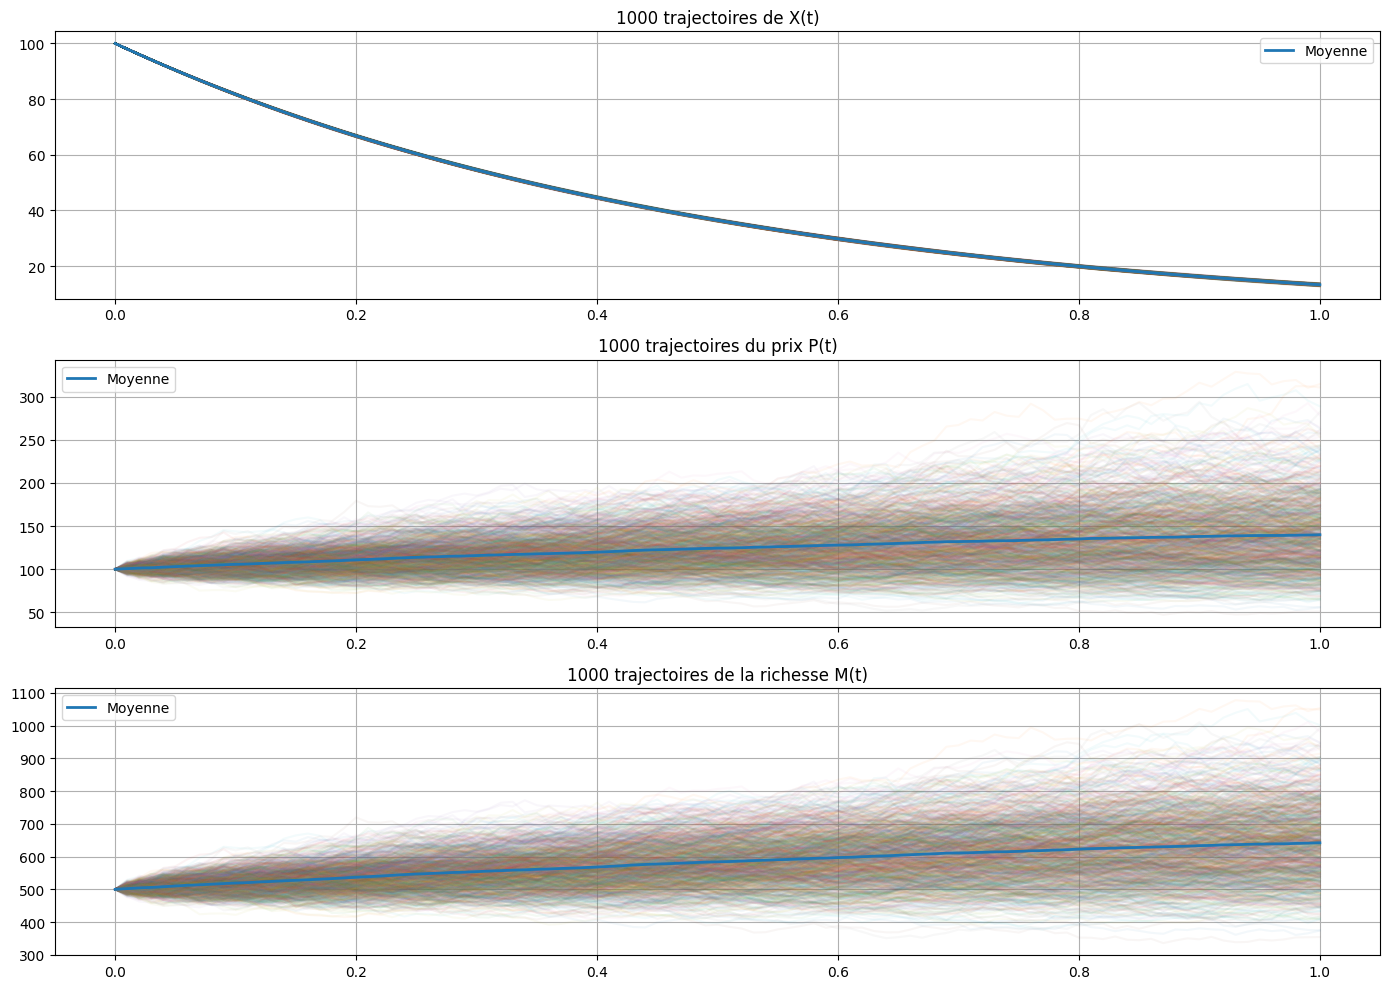

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

r = 0.07
T = 1
nu = 0.12
sig1 = 0.3
sig2 = 0.4
p = 2
l = 0.005
N = 100
mc = 1000  
dt = T / N
O = 0.6


X_all = np.zeros((mc, N+1))
P_all = np.zeros((mc, N+1))
M_all = np.zeros((mc, N+1))


X_all[:, 0] = 100
M_all[:, 0] = 500
P_all[:, 0] = 100

for k in range(mc):
    for i in range(N):
        X_all[k, i+1] = X_all[k, i] - p * X_all[k, i] * dt + sig2 * np.sqrt(dt) * np.random.randn()
        P_all[k, i+1] = P_all[k, i] * (1 + (nu + l * X_all[k, i]) * dt + sig1 * np.sqrt(dt) * np.random.randn())
        M_all[k, i+1] = M_all[k, i] * (1 + O * (P_all[k, i+1] - P_all[k, i]) / P_all[k, i] 
                                      + nu * (1 - O) * dt)


X_mean = np.mean(X_all, axis=0)
P_mean = np.mean(P_all, axis=0)
M_mean = np.mean(M_all, axis=0)


t = np.linspace(0, T, N+1)


plt.figure(figsize=(14, 10))

# X(t)
plt.subplot(3,1,1)
for k in range(mc):
    plt.plot(t, X_all[k], alpha=0.05)
plt.plot(t, X_mean, linewidth=2, label="Moyenne")
plt.title("1000 trajectoires de X(t)")
plt.grid(True)
plt.legend()

# P(t)
plt.subplot(3,1,2)
for k in range(mc):
    plt.plot(t, P_all[k], alpha=0.05)
plt.plot(t, P_mean, linewidth=2, label="Moyenne")
plt.title("1000 trajectoires du prix P(t)")
plt.grid(True)
plt.legend()

# M(t)
plt.subplot(3,1,3)
for k in range(mc):
    plt.plot(t, M_all[k], alpha=0.05)
plt.plot(t, M_mean, linewidth=2, label="Moyenne")
plt.title("1000 trajectoires de la richesse M(t)")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

#faire la probabilité et la suite des questions 

options

1.6526614088230167


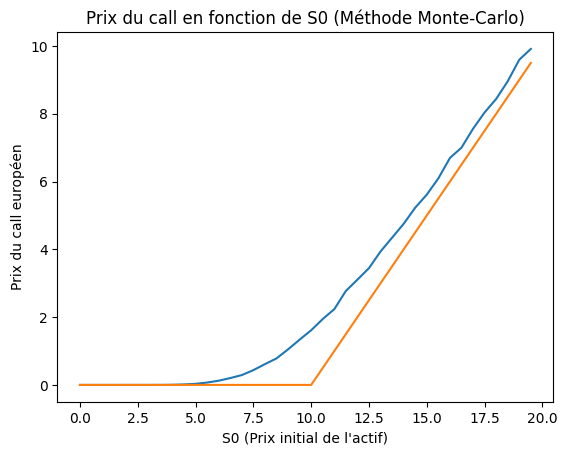

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def prix_call(S0=10, r=0.1, sigma=0.5, T=0.5, K=10, Nmc=10000):
    gains = np.zeros(Nmc)
    for n in range(Nmc):
        S_t = S0 * np.exp((r - sigma**2 / 2) * T + sigma * np.sqrt(T) * np.random.randn())
        gains[n] = np.maximum(S_t - K, 0)
    prix = np.exp(-r * T) * np.mean(gains)
    return prix

def graphe_call():
    K = 10
    S_0 = np.arange(0, 20, 0.5)
    prix = np.zeros_like(S_0, dtype=float)
    payoff = np.maximum(S_0 - K, 0)

    for j in range(len(S_0)):
        S_0[j] = j * 0.5
        prix[j] = prix_call(S_0[j])

    plt.plot(S_0, prix)
    plt.plot(S_0, payoff)
    plt.xlabel("S0 (Prix initial de l'actif)")
    plt.ylabel("Prix du call européen")
    plt.title("Prix du call en fonction de S0 (Méthode Monte-Carlo)")
    plt.show()

print(prix_call())
graphe_call()



1.4630650249782906


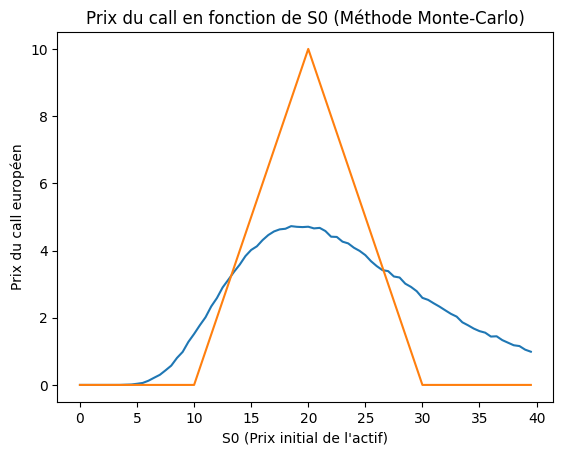

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def prix_call(S0=10, r=0.1, sigma=0.5, T=0.5, K=10, Nmc=10000):
    gains = np.zeros(Nmc)
    for n in range(Nmc):
        S_t = S0 * np.exp((r - sigma**2 / 2) * T + sigma * np.sqrt(T) * np.random.randn())
        gains[n] = np.maximum(S_t - K, 0) +np.maximum(S_t - 3*K, 0) - 2*np.maximum(S_t - 2*K, 0)
    prix = np.exp(-r * T) * np.mean(gains)
    return prix

def graphe_call():
    K = 10
    S_t = np.arange(0, 40, 0.5)
    prix = np.zeros_like(S_t, dtype=float)
    payoff = np.maximum(S_t - K, 0) + np.maximum(S_t - 3*K, 0) - 2*np.maximum(S_t - 2*K, 0) #butterfly

    for j in range(len(S_t)):
        prix[j] = prix_call(S_t[j])

    plt.plot(S_t, prix)
    plt.plot(S_t, payoff)
    plt.xlabel("S0 (Prix initial de l'actif)")
    plt.ylabel("Prix du call européen")
    plt.title("Prix du call en fonction de S0 (Méthode Monte-Carlo)")
    plt.show()

print(prix_call())
graphe_call()

butterfly c'est quand le prix est stable et si je sens que ca augemente je prends l'autre. Connaitre les equa diff stochastiques pour calculer n'importe quel produit dérivée